# Analysis of MNase-seq replication timing

March 25, 2024

This notebook aims to examine the raw MNase-seq data and compare to the Brewer replication timing.



In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [167]:
from cc_src.mnase_replication_timing_analysis import MNaseOriginAnalysis

In [172]:
mnase_analysis = MNaseOriginAnalysis()

In [522]:
replicate = 2
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

Replicate: 2, 10
chrom read timepoints: [  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
[  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]


In [630]:
mnase_analysis.compute_sliding_window_counts_all_times()

In [757]:
mnase_analysis.normalize_samples()

Text(0.5, 1.0, 'Normalized read counts, accounting for copy number')

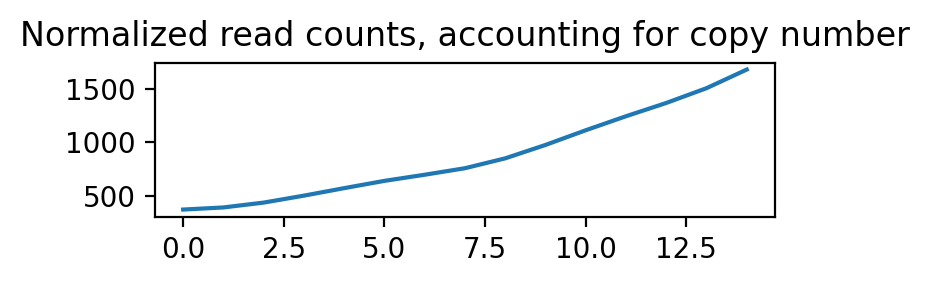

In [758]:
plt.figure(figsize=(4, 1))
plt.plot(mnase_analysis.sample_normalized.sum(axis=1))
plt.title("Normalized read counts, accounting for copy number")

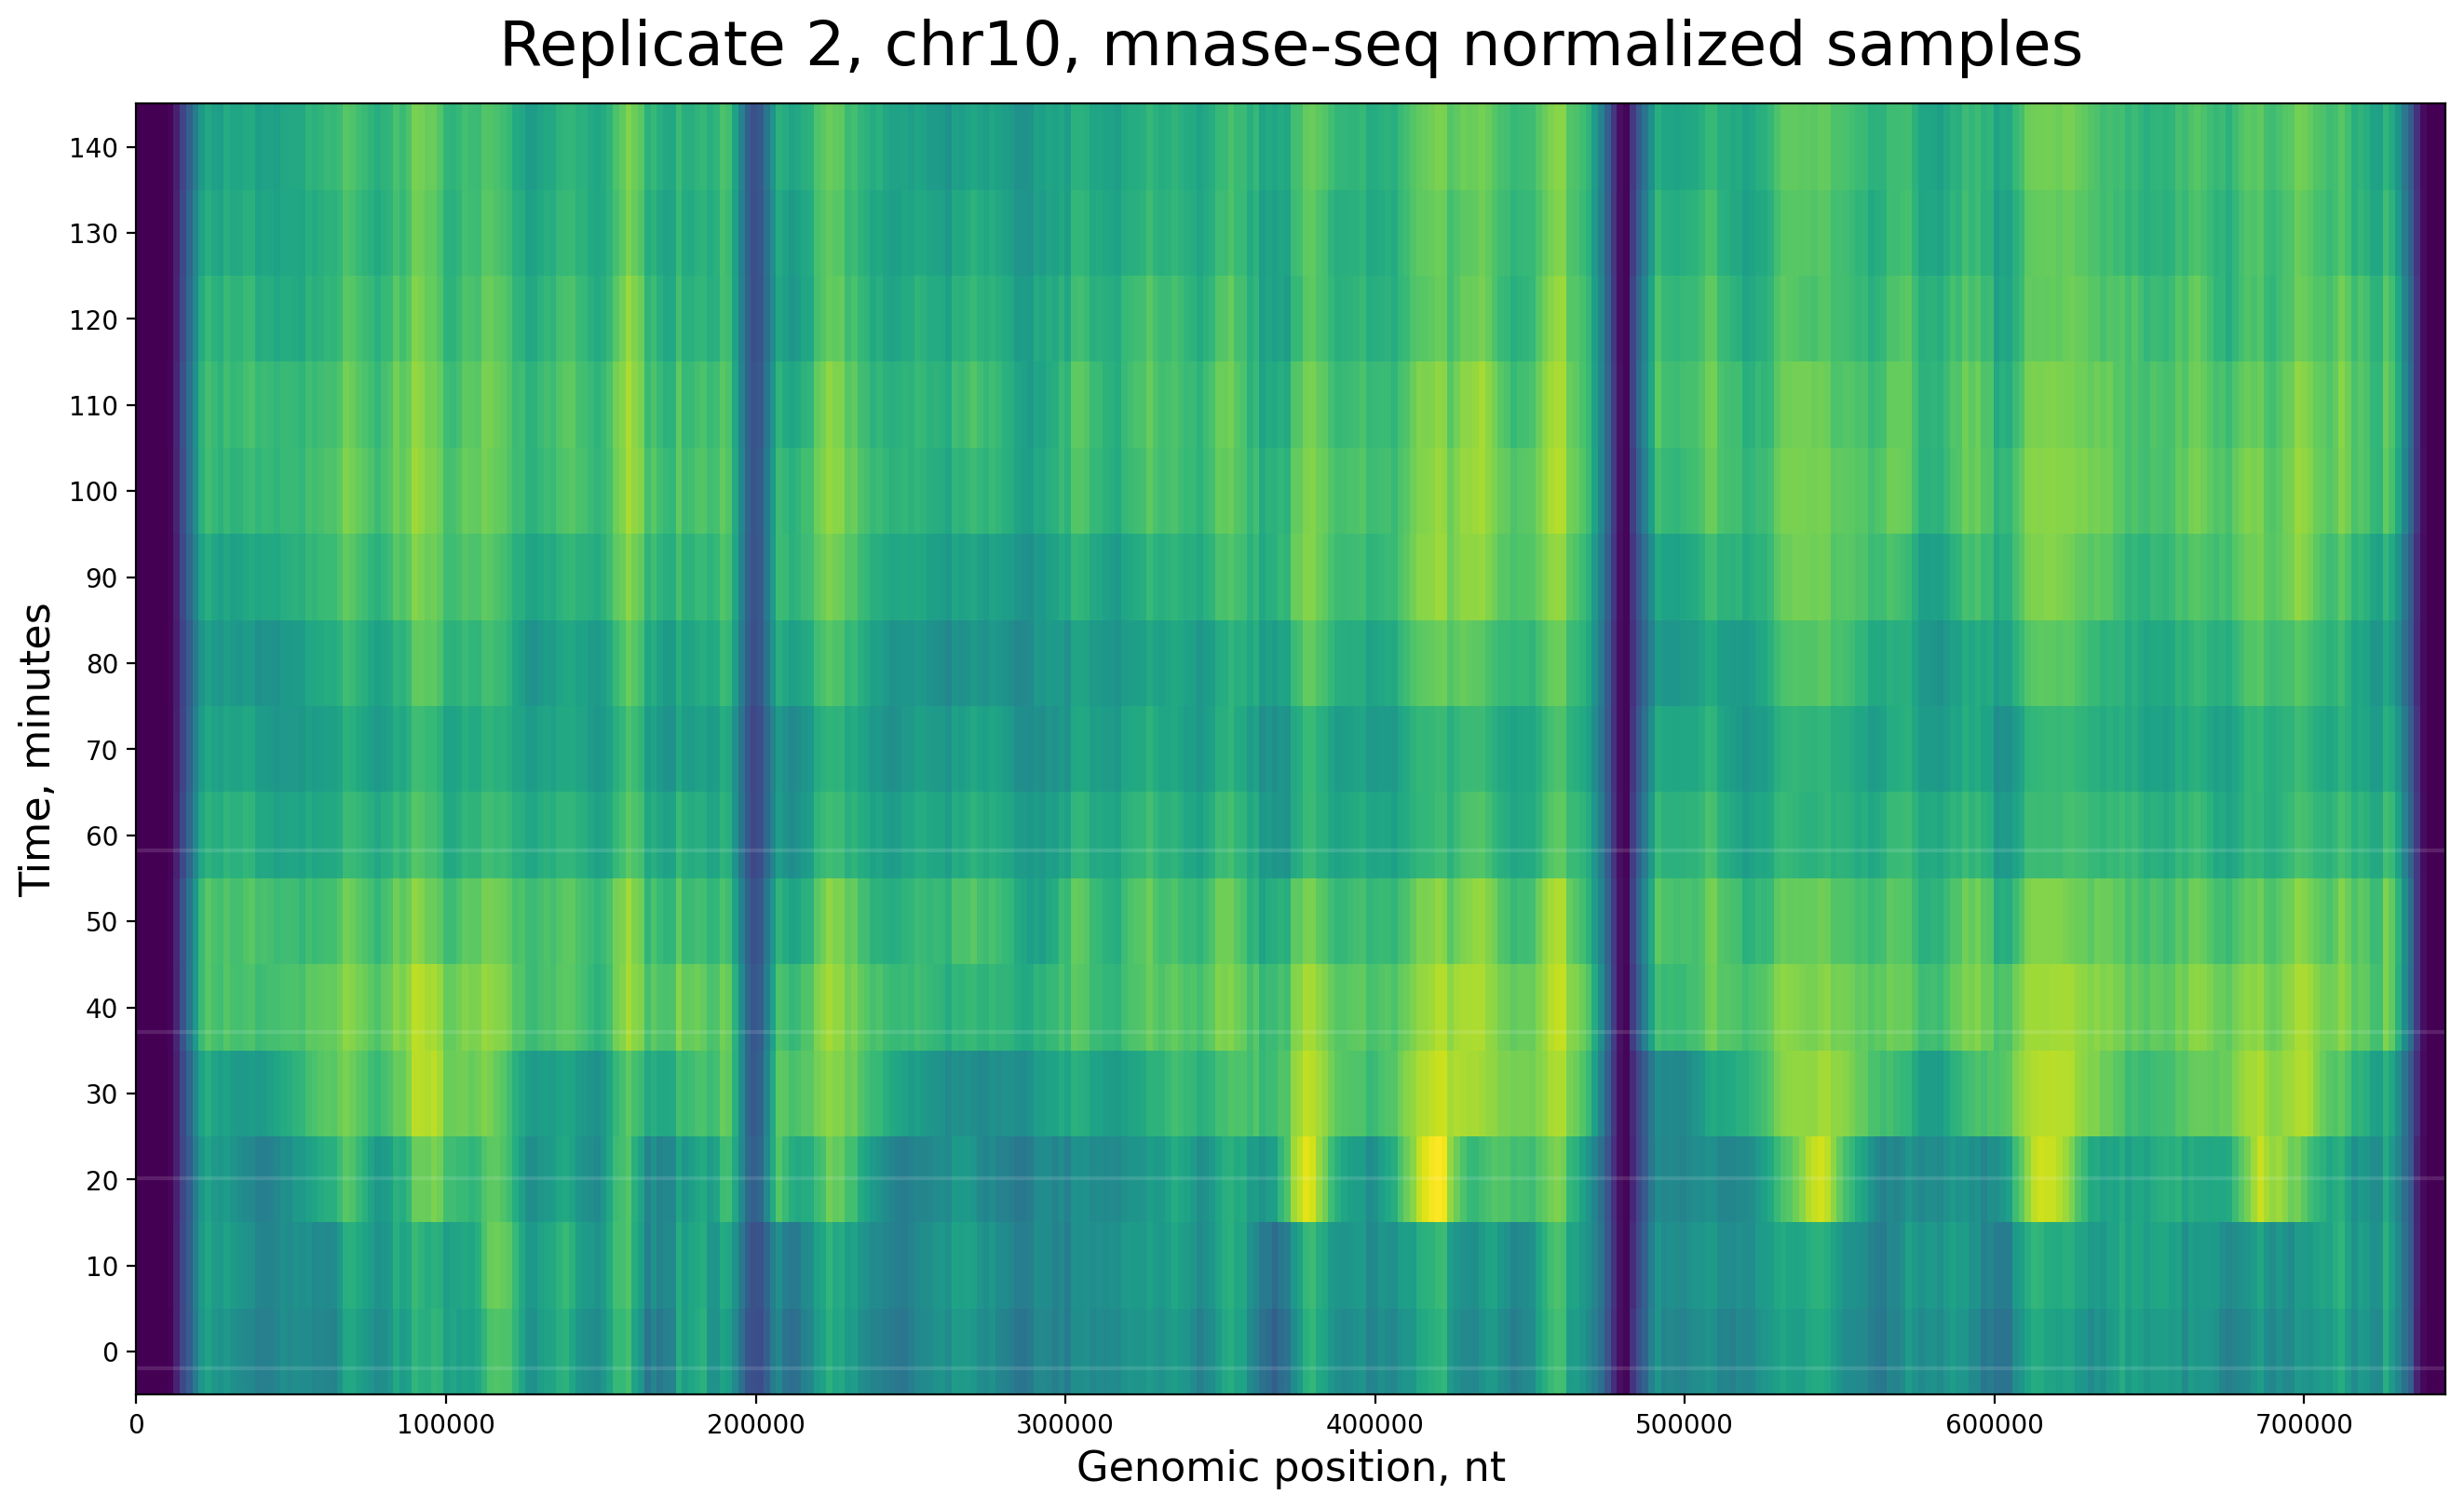

In [759]:
mnase_analysis.plot_heatmap()

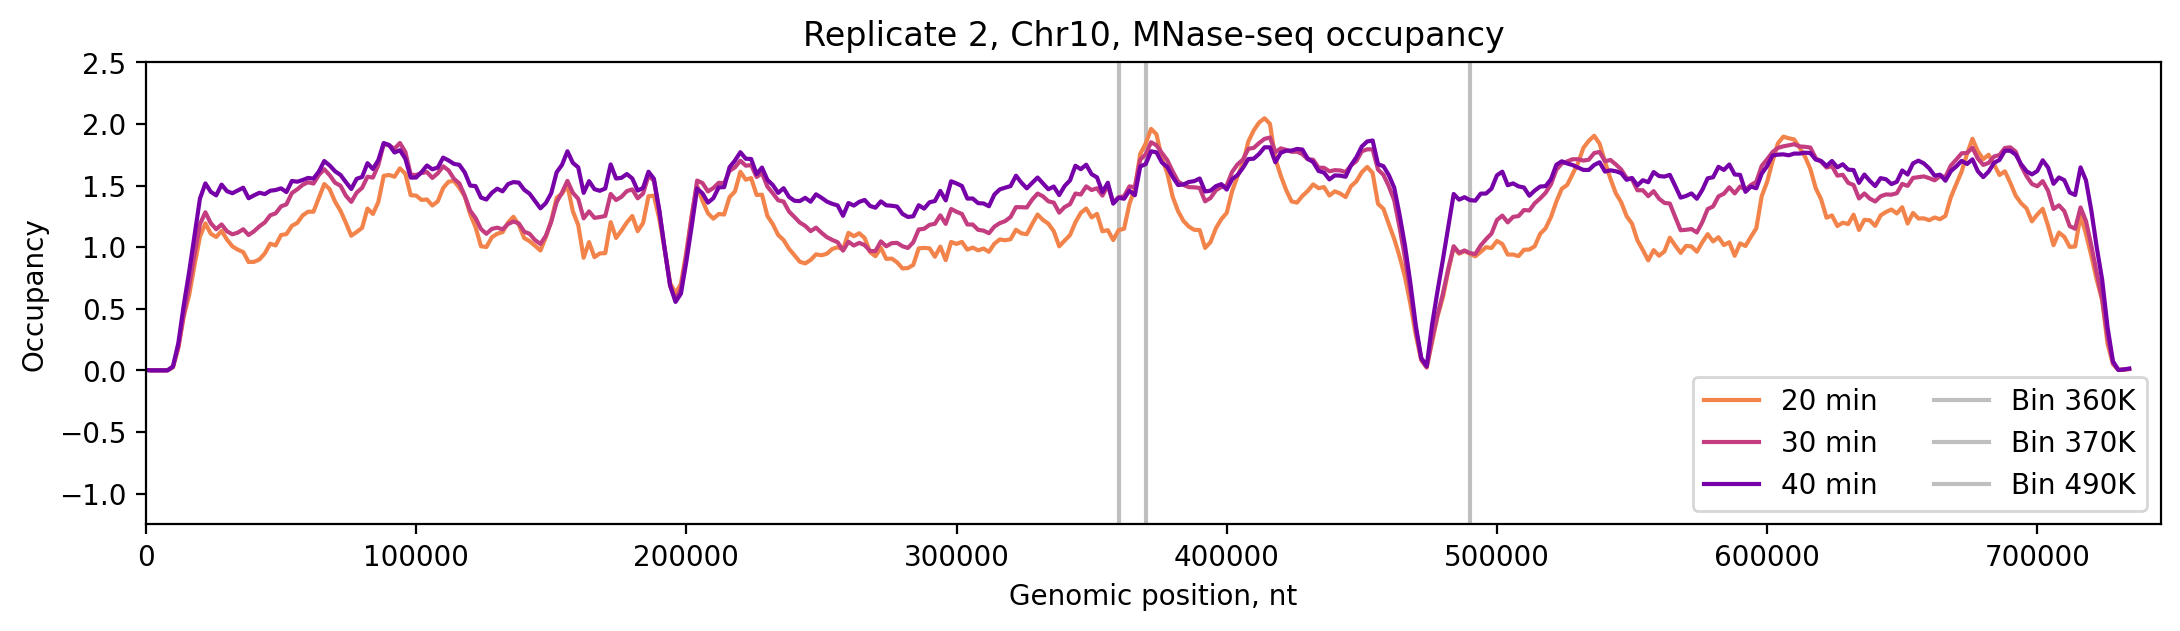

In [907]:
selected_bins=[180, 185, 245]
time_indices=[2, 3, 4]
mnase_analysis.plot_bin_occupancy_for_selected_timepoints(time_indices, selected_bins)

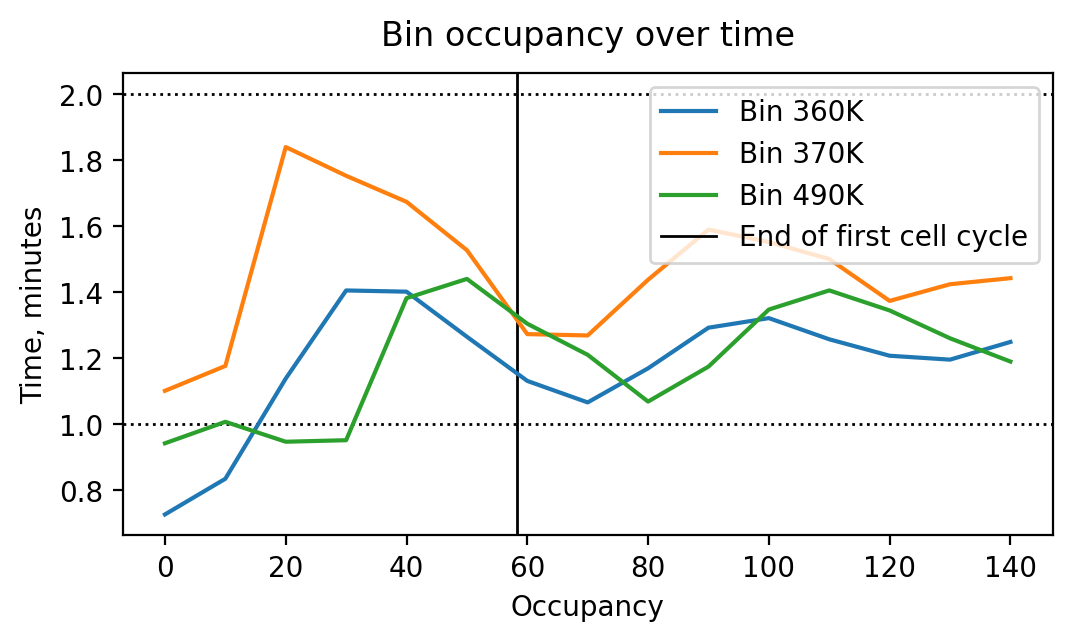

In [908]:
mnase_analysis.plot_selected_bin_occupancy(selected_bins)

In [909]:

def get_replication_timing(occupancy_counts, timepoints):

    # Threshold for determining when a bin has replicated
    min_values = occupancy_counts.min(axis=0)
    max_values = occupancy_counts.max(axis=0)

    thresh_prop = 0.75
    thresholds = min_values + (max_values - min_values) * thresh_prop

    exceeds_threshold = occupancy_counts > thresholds
    replication_timing_idx = np.argmax(exceeds_threshold, axis=0)

    replication_timepoints = timepoints[replication_timing_idx]
    
    return replication_timepoints


In [910]:

replication_timepoints = get_replication_timing(bin_counts, mnase_analysis.timepoints)


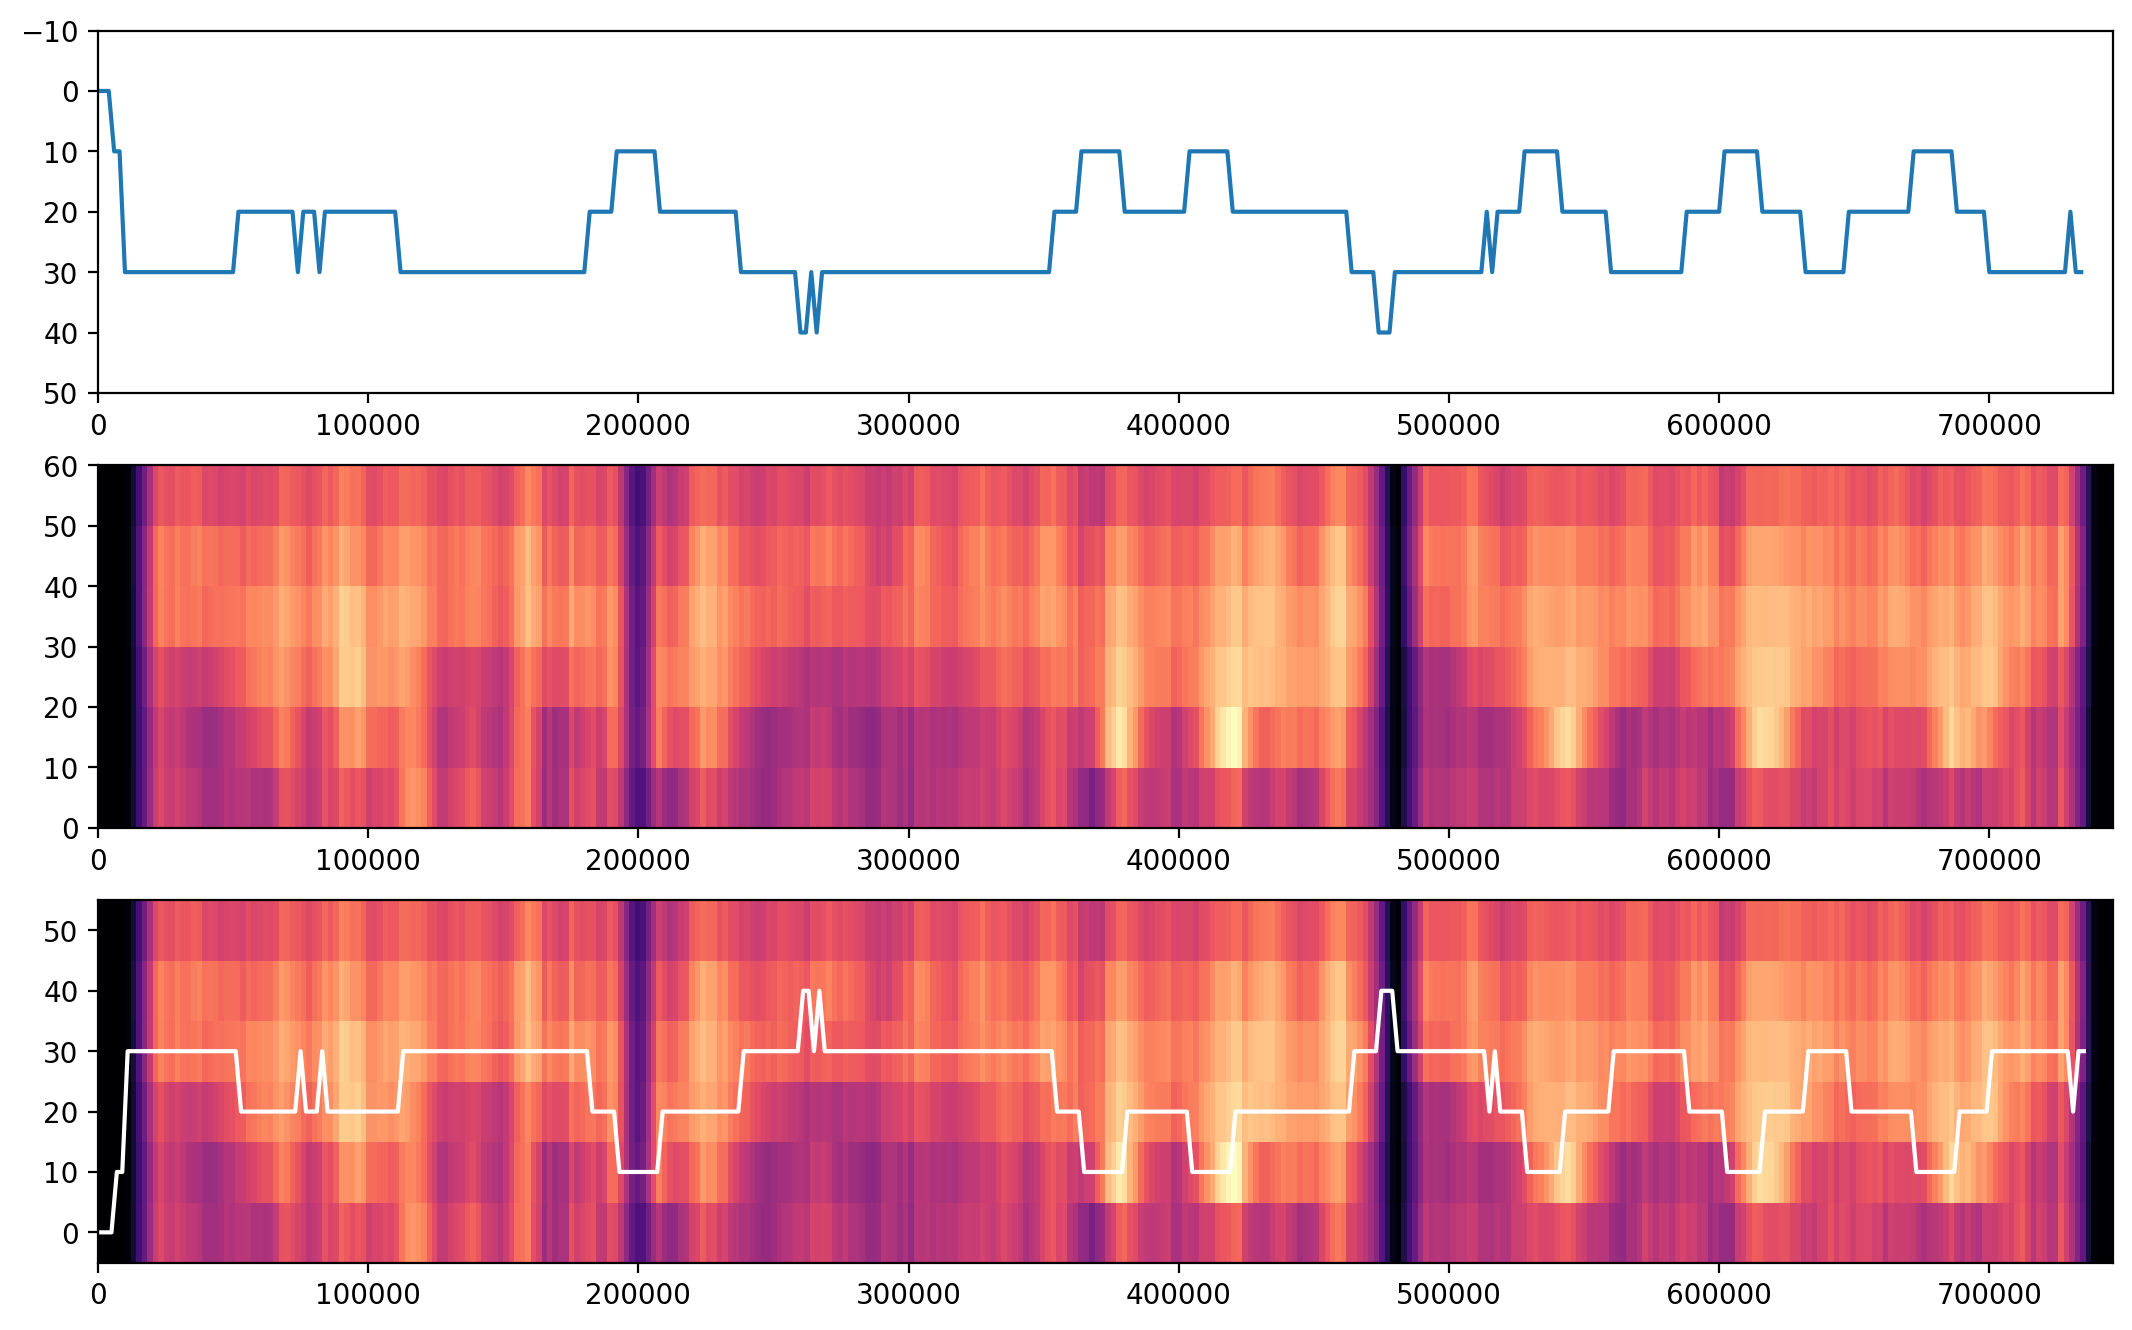

In [911]:
bin_counts = mnase_analysis.counts_normalized_by_copy[1:7, :]

plt.figure(figsize=(13, 8))

plt.subplot(3, 1, 1)
plt.plot(mnase_analysis.start_indices, replication_timepoints)
plt.ylim(50, -10)
plt.xlim(0, mnase_analysis.chrom_len)

plt.subplot(3, 1, 2)
plt.imshow(bin_counts, origin='lower', aspect='auto', 
           cmap='magma',
           extent=[0, mnase_analysis.chrom_len,
                  0, 60],
           interpolation=None)

plt.subplot(3, 1, 3)
plt.imshow(bin_counts, origin='lower', aspect='auto',
           cmap='magma',
           extent=[0, mnase_analysis.chrom_len,
                  -5, 55],)
plt.plot(mnase_analysis.start_indices+mnase_analysis.step/2., 
    replication_timepoints, c='white')
